# Graph theoric models

- We want to build models in code that we can then run to predict effects and we've seen that we can take an informal problem (choose what to eat) and find code to solve it

- We've seen two methods, greedy and dynamic programming, now we are going to look at graph models

- **What is a graph?**: the graph has two elements, the nodes (some times called vertices). Those nodes probably have information associated with it (could be the name of a student, or its grades). *important: "edge" here is not like "punta, o esquina" is just the connection between two nodes*

- **We want to know what are the connections between the elemetns of my system**. The second thing we want to have are **edges**, an edge will connect a pair of nodes
- We can build two ways to build graphs using edges, the first one is the simple one:
    - Undirected graph: An edge connects two nodes together and allows sharing information between both of them
    - Directed diagraph: in which case the edge has a direction from a source to a destination (parent to a child), the information only flow from the source to a child

- Those edges could just be connection or we can put information on them, like weights (how much effort is it going to take to going from source to the destination)
- But... **why we want them?**: therer are different application, rail links between paris and london, how the atoms in a molecule are related or ancestral relatiionshps.

- Actually decision trees are just a special case of a graph! It is just a graph with a property that any pair of nodes are connected by only a single path, no loops!

- But... **Why are they usefull?** : world is full of networks based on relationships! computer networks, transportaion, financial, political, socia, etc. Graphs capture relationships between the nodes, but... they also can inference, predict! Is there a sequence of edges that we can use to get from A to B? if we can find the least expensive path? is there a way to sepparate out highly connected structures?

- Something interesting that we can to with graphs is that we can cluster nodes! Categorizing them, which clusters in the graph tend to have interaction with their cluster but not with others? 

- For example, if we'd wanted to model the road system we should use directed graphs, because streets only can be one way, and so we can only have one single direction:
    - The nodes will be points where are intersections, they are places where we can make a choice!
    - The edges will just be the connections between points 
    - Each edge will have a weight, they could represent the expected time between the source and the destination, or we can just pick distance, or even the average speed or travel!
    - Optimization problem: what is the shortes weight between my house and my office that gets me into work? 

- The first famouse problem solved using graphs was the bridges of Konigsberg in 1735, it is possible to take a walk that traversees each of the 7 bridges eaxtl once?. This was solved by Euler, and he said: make each island a node , each bride is just an undirected edge and notice how doing that we don't care about the size of the islands, about how long the bridges are, just thinkg about what are the connection there. Euler showed that the answer is NO... This kind of problems can be solved with graphs


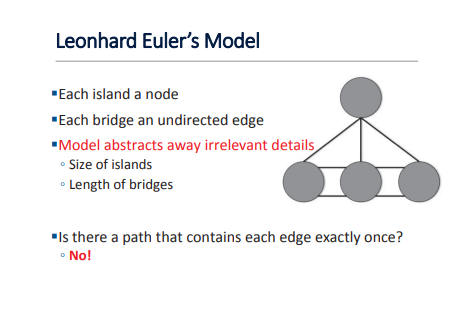
    

## Class Node

In [10]:
# lets create a simple one, with the only information: the name
class Node:

    def __init__(self, name):
        """Assumes name is a string"""
        self.name = name

    def getName(self):
        return self.name

    def __str__(self):
        return self.name

In [11]:
# we are going to build an edge with to values, source and destination
class Edge:
    def __init__(self, src, dest):
        """Assumes src and dest are nodes"""

        self.src = src
        self.dest = dest

    def getSource(self):
        return self.src

    def getDest(self):
        return self.dest

    def __str__(self):
        return self.src.getName() + "->" + self.dest.getName()

**And what do we do with these classes??**:

- Given all the sources and all the destinations, I could just create a big matrix called an adjacency matrix

- The roads will be all the sources, the columns will be all the destinations, and if there is an edge between a source and a destination we put a 1, otherwise a 0.

- Note that because this is a directed graph is not symmetric,, there might be 1 between S and D but not D to S.

- That would be a reasonable way to represnet a grpah but it may also note be an efficient way to reprsented it because if we have very few edges in the graph we could have a huge matrix with mostly zeros

- An alternative is adjancency, for any node in the graph we are going to associated with a list of destionations. For a node, what are the palces that we can reach?



In [12]:
# first we are going to build a digraph, a graph with only 1 destination, from src to dests
class Digraph:
    """edges are dictionaries mapping each node to a list of its children"""

    def __init__(self):

        self.edges = {}

    def addNode(self, node):

        # first we check if the node is already in the dic
        # nodes are represented as keys in dictionary

        if node in self.edges:
            raise ValueError("Duplicade Node")
        else:
            self.edges[node] = []

    def addEdge(self, edge):

        # we need both nodes already in the dictionary to add the destination in their lists
        # edges are represented by destinations as values in list associated with a source key

        src = edge.getSource()
        dest = edge.getDest()

        if not (src in self.edges and dest in self.edges):
            raise ValueError("Node not in graph")

        self.edges[src].append(dest)

    def childrenOf(self, node):
        # given a node I want to know what are its destinations (children)
        return self.edges[node]

    def hasNode(self, node):
        # we just want to check if the node is already in the diagram
        return node in self.edges

    def getNode(self, name):
        # we want to look for a name in the diagram, if is not, we raise a name error
        for n in self.edges:
            if n.getName() == name:
                return n
        raise NameError(name)

    def __str__(self):
        # we are just listing all the edges and their respective src and destionations in the diagram
        result = ""
        for src in self.edges:
            for dest in self.edges[src]:
                result = result + src.getName() + "->" + dest.getName() + "\n"

        return result[:-1]  # omit final newline

In [13]:
# now we are going to reuse the Digraph class and methods to build the graph, were we can have different destinations
class Graph(Digraph):

    def addEdge(self, edge):
        # first we add the edge (src and destination) using the method that we already build
        Digraph.addEdge(self, edge)
        # then we reverse that edge, we recreate it, placing the destination in the src, and the src in the destination
        rev = Edge(edge.getDest(), edge.getSource())
        Digraph.addEdge(self, rev)

**if we asked ourselves: why did we pick graph to be a subclass to digraph? and not the other way?**

- **the answer is:** we want the property that if the client code works correctly using an instance of the bigger type, it should also work correctly when it is using an instance of the subtype substitued in

- anything that works for the 'digraph' class will also work fro graph and not viceversa, and as a consequence it is easier to make the graph as a subclass of digraph.

- Other interesting property is that we built one piece of code, that only changes the definition of an edge.

- This is interesting for inheritance, a subclass must behave like its parent, but with more specific rules. A digraph cannot be treated as a graph because it does not satisfy the structural guraantees (like symmetric edges) that graph code relies on

In [14]:
def printPath(path):
    """Assumes ath is a list of nodes"""

    result = ""
    for i in range(len(path)):
        result = result + str(path[i])

        if i != len(path) - 1:
            result = result + "->"

    return result

In [15]:
def buildCityGraph(graphType):
    g = graphType()
    for name in (
        "Boston",
        "Providence",
        "New York",
        "Chicago",
        "Denver",
        "Phoenix",
        "Los Angeles",
    ):  # Create 7 nodes

        g.addNode(Node(name))

    g.addEdge(Edge(g.getNode("Boston"), g.getNode("Providence")))
    g.addEdge(Edge(g.getNode("Boston"), g.getNode("New York")))
    g.addEdge(Edge(g.getNode("Providence"), g.getNode("Boston")))
    g.addEdge(Edge(g.getNode("Providence"), g.getNode("New York")))
    g.addEdge(Edge(g.getNode("New York"), g.getNode("Chicago")))
    g.addEdge(Edge(g.getNode("Chicago"), g.getNode("Denver")))
    g.addEdge(Edge(g.getNode("Chicago"), g.getNode("Phoenix")))
    g.addEdge(Edge(g.getNode("Denver"), g.getNode("Phoenix")))
    g.addEdge(Edge(g.getNode("Denver"), g.getNode("New York")))
    g.addEdge(Edge(g.getNode("Los Angeles"), g.getNode("Boston")))

    return g

In [16]:
x = buildCityGraph(Digraph)

In [17]:
print(x)

Boston->Providence
Boston->New York
Providence->Boston
Providence->New York
New York->Chicago
Chicago->Denver
Chicago->Phoenix
Denver->Phoenix
Denver->New York
Los Angeles->Boston


## Depth first search:

**what is the fastest way to got from a point a to a point b?**

It is called depth first , we are going as deep if you like, in this grpah as we can

1. Start at an initial node

2. Consider all the edges that leave that node, in some order

3. Follow the first edge, and check to see if weare at the goal node

4. if not, repeat the process from a new node

5. Continue until either we find the goal node, or we run out of options
    - When run out of options, we should backtrack to the previous node an try the next edge, repeating this process

In [18]:
def DFS(graph, start, end, path, shortest, toPrint=False):

    # the path will be a list with all the nodes that we are going to travel to
    path = path + [start]

    if toPrint:
        print("Current DFS path", printPath(path))

    if start == end:

        return path
    # for each direction in the current node we are going to travel until the end
    for node in graph.childrenOf(start):
        if node not in path:  # avoid cycles

            # if the shortest path has more elements than the new visited path, we delve into that path
            if shortest == None or len(path) < len(shortest):

                # if we are on the first iteration, the 'shortest' variable do not exist
                # so we are travel inside the node
                newPath = DFS(graph, node, end, path, shortest, toPrint)

                # if we find a path we store it as the new shortest path
                if newPath != None:
                    shortest = newPath

        elif toPrint:
            print("Already visited", node)

    return shortest

In [19]:
def shortestPath(graph, start, end, toPrint=False):
    return DFS(graph, start, end, [], None, toPrint)

In [20]:
g = buildCityGraph(Digraph)
print(g)

Boston->Providence
Boston->New York
Providence->Boston
Providence->New York
New York->Chicago
Chicago->Denver
Chicago->Phoenix
Denver->Phoenix
Denver->New York
Los Angeles->Boston


In [21]:
def testSP(source, destination):
    g = buildCityGraph(Digraph)
    sp = shortestPath(g, g.getNode(source), g.getNode(destination), toPrint=True)

    if sp != None:
        print("Shortest path from ", source, "to", destination, "is ", printPath(sp))

    else:
        print("There is not path from", source, "to", destination)

## Lets test our DPS algorithm

In [22]:
testSP("Chicago", "Boston")

Current DFS path Chicago
Current DFS path Chicago->Denver
Current DFS path Chicago->Denver->Phoenix
Current DFS path Chicago->Denver->New York
Already visited Chicago
Current DFS path Chicago->Phoenix
There is not path from Chicago to Boston


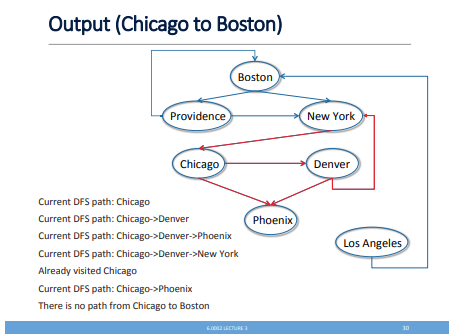

In [23]:
testSP("Boston", "Phoenix")

Current DFS path Boston
Current DFS path Boston->Providence
Already visited Boston
Current DFS path Boston->Providence->New York
Current DFS path Boston->Providence->New York->Chicago
Current DFS path Boston->Providence->New York->Chicago->Denver
Current DFS path Boston->Providence->New York->Chicago->Denver->Phoenix
Already visited New York
Current DFS path Boston->Providence->New York->Chicago->Phoenix
Current DFS path Boston->New York
Current DFS path Boston->New York->Chicago
Current DFS path Boston->New York->Chicago->Denver
Current DFS path Boston->New York->Chicago->Denver->Phoenix
Already visited New York
Current DFS path Boston->New York->Chicago->Phoenix
Shortest path from  Boston to Phoenix is  Boston->New York->Chicago->Phoenix


## Breadth first search

Here is another way to solve this problem:

1. Start at an initial Node

2. Consider all the edges that leave that node, in some order

3. Follow the first edge, and check to see if at goal Node

4. If not, try the next edge from the current node

5. Continue until either find goal node, or run out of options
    - When run out of  edge options, move to next node at same dinstance from start, and repeat
    - When run out of node options, move to next level in the graph (all nodes one step further from start), and repeat

From my perspective DFS go as deep as possible before backtracking (A -> B -> C)
While BFS explore all nodes at distance 1, then 2, then 3... Like having levels and check at each level instead of picking a path. We check each children level before going deeper.

In [24]:
def BFS(graph, start, end, toPrint=False):
    # first we store the initial path in a list , and we store that list inside another list (pathqueue)
    initPath = [start]
    pathQueue = [initPath]
    # in the llop, we will stop when we reach the end or when we exhaust all possible paths
    while len(pathQueue) != 0:
        # we stored the oldest element in the queue,
        # so in the first iteration we will left the last pathQueue with 0 elements!
        tmpPath = pathQueue.pop(0)
        if toPrint:
            print("Current BFS path", printPath(tmpPath))
        lastNode = tmpPath[-1]
        # in the first iteration, last node will be just the start point
        if lastNode == end:
            return tmpPath

        # if the start point is not the end piont, we will iterate through the children of the starting point
        for nextNode in graph.childrenOf(lastNode):
            # if we are not revisting the same path, we will consider as a new path to explore later,and we will store the whole path to the path queue
            # for next checkings
            if nextNode not in tmpPath:
                newPath = tmpPath + [nextNode]
                pathQueue.append(newPath)
    return None

In [25]:
def shortestPath(graph, start, end, toPrint=True):
    """
    Assumes that the graph is a Digraph,
    start and end are nodes,
    Returns a shortest path from start to end in graph"""

    return BFS(graph, start, end, toPrint)


def testSP(source, destination):
    g = buildCityGraph(Digraph)
    sp = shortestPath(g, g.getNode(source), g.getNode(destination), toPrint=True)

    if sp != None:
        print("Shortest path from ", source, "to", destination, "is ", printPath(sp))

    else:
        print("There is not path from", source, "to", destination)

In [26]:
testSP("Boston", "Phoenix")

Current BFS path Boston
Current BFS path Boston->Providence
Current BFS path Boston->New York
Current BFS path Boston->Providence->New York
Current BFS path Boston->New York->Chicago
Current BFS path Boston->Providence->New York->Chicago
Current BFS path Boston->New York->Chicago->Denver
Current BFS path Boston->New York->Chicago->Phoenix
Shortest path from  Boston to Phoenix is  Boston->New York->Chicago->Phoenix


**at each stage we are taking the top thing of the queue, asking for all the things that we can get to and adding them to it**
- In some cases more than 1 time
- First all the paths with len 1, exhausted those, the all the paths with legth 2, and three... 


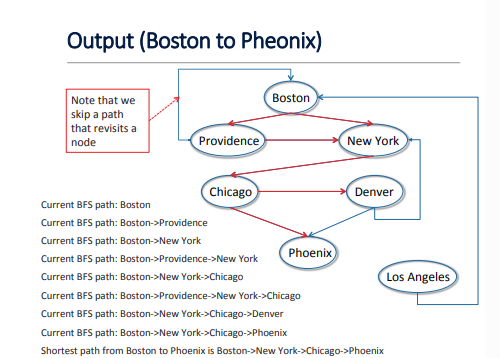


- And what about weighted shortest path? the idea would be imagine on the edges not only a step but also a weight (time, money) 
- It will be the same kind of optimization but instead of (len) minizmiing the sum of the weights!
- Depth first search woudl be easy modify to do that, the cost now would be the sum of those weights, and we would have to search all possible options till we find the solution.
- BFS can't be easily modify because the short weighted path may have many more than the mininum number of loops and we have to think how to adjust it to make tha happen